In [1]:
import k_fail_MBTR
import BB_wrapper
import k_fail_prediction

import torch

/Users/karim/projects/k-sPSS/.venv/lib/python3.11/site-packages/pycutest/__init__.py:26: RuntimeWarning: the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.
  warnings.warn("the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.", RuntimeWarning)


# Test Set

In [2]:
cap_n_problems = 24

cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt", max_dim=100, cap_n_problems=cap_n_problems,
                problem_names=[
    "SISSER",
    # "CHWIRUT2LS",
    "DENSCHNB", "GBRAINLS",
    # "MGH10LS",
    "QING",
    # "BOX3",
    "DENSCHNC",
    # "LANCZOS3LS",
    # "GAUSS1LS",
    "MGH09LS",
    # "LANCZOS1LS",
    # "BA-L1LS",
    # "GAUSS3LS",
    "DENSCHNA",
    # "NELSONLS",
    "LUKSAN21LS", "VANDANMSLS",
    "SENSORS",
    # "DENSCHND",
    # "DANWOODLS",
    "CUBE", "MUONSINELS",
    # "DENSCHNE",
    "DMN15333LS", "DIAMON3DLS",
    # "EXPFIT",
    "HELIX", "LSC2LS", "KOWOSB",
    "S308", "DANIWOODLS", "DENSCHNF", "LRIJCNN1", "YFITU",
    # "GAUSS2LS",
    # "CHWIRUT1LS",
    "COOLHANSLS", "HAHN1LS",
    # "HIMMELBB",
                ])
# problem idx: 6 gets <= -1e20
# problem idx: 8 gets <= -1e20
# problem idx: 11 gets <= -1e20
# problem idx: 20 gets <= -1e20

# BOX3
# LANCZOS3LS
# LANCZOS1LS
# DANWOODLS
# CHWIRUT2LS
# MGH10LS
# GAUSS1LS
# BA-L1LS
# GAUSS3LS
# NELSONLS
# DENSCHND
# DENSCHNE
# EXPFIT a
# GAUSS2LS
# CHWIRUT1LS
# HIMMELBB

loading problems...
0/24
20/24
loaded 24 problems


In [3]:
# evaluating n problem functions
for i in range(cap_n_problems):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | DENSCHNB | n: 2: 6.0
idx: 2 | GBRAINLS | n: 2: 41.0311021275977
idx: 3 | QING | n: 100: 328350.0
idx: 4 | DENSCHNC | n: 2: 889.3031475218829
idx: 5 | MGH09LS | n: 4: 897.5453780404945
idx: 6 | DENSCHNA | n: 2: 7.952492442012559
idx: 7 | LUKSAN21LS | n: 100: 99.98750720029557
idx: 8 | VANDANMSLS | n: 22: 15.000017496625823
idx: 9 | SENSORS | n: 100: -56.48140005456502
idx: 10 | CUBE | n: 2: 749.0383999999999
idx: 11 | MUONSINELS | n: 1: 61302.97680759
idx: 12 | DMN15333LS | n: 99: 484133.4482526387
idx: 13 | DIAMON3DLS | n: 99: 4028942.9527573423
idx: 14 | HELIX | n: 3: 2499.999798289702
idx: 15 | LSC2LS | n: 3: 235144.35341171772
idx: 16 | KOWOSB | n: 4: 0.005313615358191823
idx: 17 | S308 | n: 2: 87.68604814559544
idx: 18 | DANIWOODLS | n: 2: 149.71921907712198
idx: 19 | DENSCHNF | n: 2: 416.0
idx: 20 | LRIJCNN1 | n: 22: 1.528013678381445
idx: 21 | YFITU | n: 3: 2340.4195868458514
idx: 22 | COOLHANSLS | n: 9: 902930.45122
idx: 23 | HAHN1L

     n num_problems
--------------------
     1            1
     2            9
     3            3
     4            2
     7            1
     9            1
    22            2
    99            2
   100            3


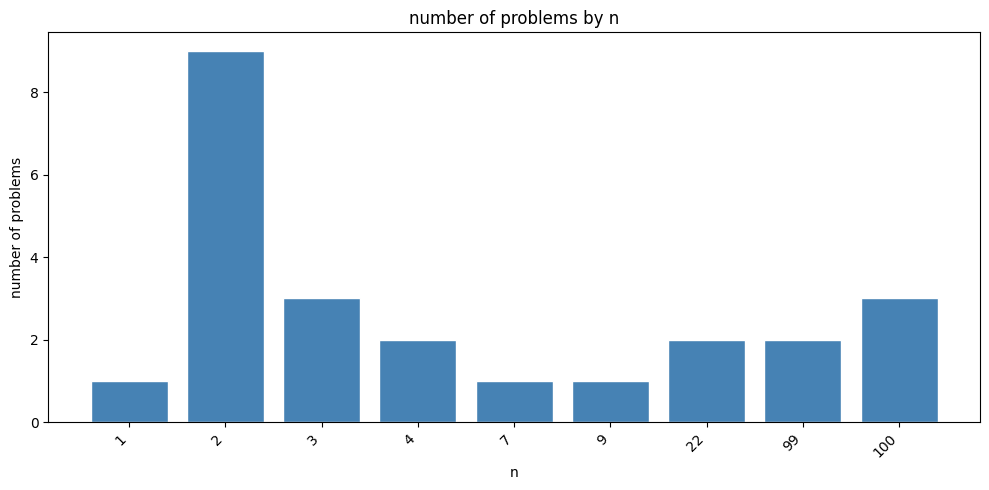

In [4]:
from collections import Counter 
import matplotlib.pyplot as plt

def count_problems_by_n(filepath: str) -> None:
    counter = Counter()
 
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('|')
            if len(parts) < 4:
                continue
            try:
                n = int(parts[3].strip())
                counter[n] += 1
            except ValueError:
                continue  # skip header or malformed lines
 
    print(f"{'n':>6} {'num_problems':>12}")
    print("-" * 20)
    for n in sorted(counter):
        print(f"{n:>6} {counter[n]:>12}")
 
    ns = sorted(counter)
    counts = [counter[n] for n in ns]
 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([str(n) for n in ns], counts, color="steelblue", edgecolor="white")
    ax.set_xlabel("n")
    ax.set_ylabel("number of problems")
    ax.set_title("number of problems by n")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

count_problems_by_n("hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt")

# Algorithm Wrappers

In [5]:
import time
import os

TIME_LIMIT_S = 120.0

def read_last_fx(filename):
    last_fx = None
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            # Skip header and empty lines
            if not line or line.startswith("k"):
                continue
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 3:
                try:
                    last_fx = float(parts[2])
                except ValueError:
                    pass
    return last_fx

In [6]:
def mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, delta, mu, eta, gamma, eps_stop, opportunistic_cpu_exploitation_manual_point_limit, preferred_model_order, n_batch_calls_limit): # eps stop also should be searched for because it is responsible for not wasting function calls, the algorithm knows when a solution is good
    log_file_path = f"alg_logs/MBTR/profile_testing_{problem_idx}_{delta:.2f}_{mu:.2f}_{eta:.2f}_{gamma:.2f}_{eps_stop:.2f}_{preferred_model_order}_{opportunistic_cpu_exploitation_manual_point_limit}_{n_batch_calls_limit}_expl_mbtr.txt"
    if os.path.exists(log_file_path):
        return log_file_path

    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

    alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=log_file_path,
                                  preferred_model_order=preferred_model_order, # cpu exploitation is on by default
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit)
    
    alg.log_current()

    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            # print("TIME LIMIT")
            with open("alg_logs/MBTR/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {problem_idx} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default()
    
    # return best function value so far
    return log_file_path

# MBTR hyperparameters and cluster settings

In [7]:
# cluster
# number of cpus will be determined for each problem manually
num_cpus_dim_brackets = [
    [4, 4], # n < 4 -> 4 cpus
    [8, 8],
    [16, 16],
    [32, 32],
    [64, 64],
    [128, 128],
]
k_ratios = [ # portion of cpus failing, will be rounded up
    0.0,
    0.05,
    0.1,
    0.2,
]


# MBTR ORDER 1
mbtr_1_delta = 1.0
mbtr_1_mu = 1.0
mbtr_1_eta = 0.1
mbtr_1_gamma = 0.5
mbtr_1_eps_stop = 0.0

# MBTR ORDER 2
mbtr_2_delta = 1.0
mbtr_2_mu = 1.0
mbtr_2_eta = 0.1
mbtr_2_gamma = 0.4
mbtr_2_eps_stop = 0.0

# Run the algorithms

In [ ]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import math

N_BATCH_LIMIT = 80

log_paths = [
    [],
    [],
    [],
    [],
    [],
    [],
]

limit_1 = lambda n: 2*n
limit_2 = lambda n: 3*n
limit_3 = lambda n: 4*n

limit option 1

In [9]:
# MBTR ORDER 1

pbar = tqdm(total=cap_n_problems * len(k_ratios))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[0].append(mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, limit_1(problem_n), 1, N_BATCH_LIMIT))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [10]:
# MBTR ORDER 2

pbar = tqdm(total=cap_n_problems * len(k_ratios))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[1].append(mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, limit_1(problem_n), 2, N_BATCH_LIMIT))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

limit option 2

In [11]:
# MBTR ORDER 1

pbar = tqdm(total=cap_n_problems * len(k_ratios))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[2].append(mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, limit_2(problem_n), 1, N_BATCH_LIMIT))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [12]:
# MBTR ORDER 2

pbar = tqdm(total=cap_n_problems * len(k_ratios))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[3].append(mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, limit_2(problem_n), 2, N_BATCH_LIMIT))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

limit option 3

In [13]:
# MBTR ORDER 1

pbar = tqdm(total=cap_n_problems * len(k_ratios))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[4].append(mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, limit_3(problem_n), 1, N_BATCH_LIMIT))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [14]:
# MBTR ORDER 2

pbar = tqdm(total=cap_n_problems * len(k_ratios))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[5].append(mbtr_expl_path_batch_constrained(problem_idx, num_cpus, k, mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, limit_3(problem_n), 2, N_BATCH_LIMIT))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

# Plot the results

In [15]:
import profiles

alg_names = ["MBTR-1 lim-1", "MBTR-2 lim-1", "MBTR-1 lim-2", "MBTR-2 lim-2", "MBTR-1 lim-3", "MBTR-2 lim-3"]
NUM_ALGS = len(alg_names)

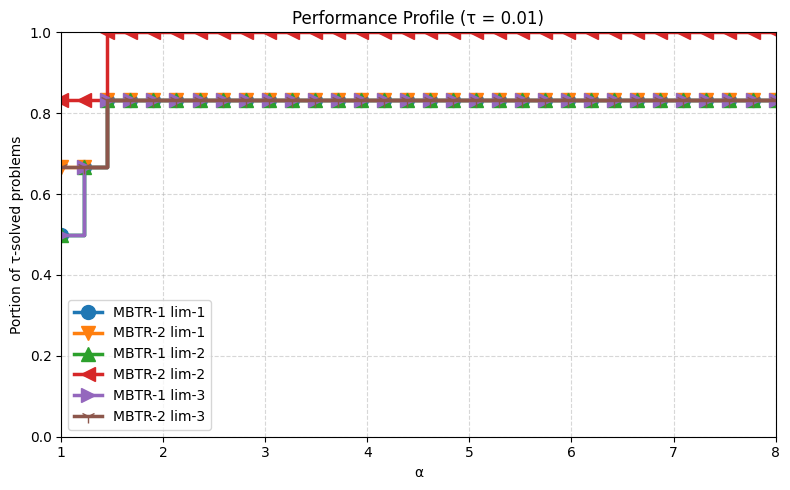

In [21]:
tau = 0.01
alpha_vals = torch.linspace(1, 8, 32)

profile_vals = profiles.performance_profile(NUM_ALGS, cap_n_problems, log_paths, tau, alpha_vals=alpha_vals)
profiles.plot_performance_profile(profile_vals, tau, alg_names, alpha_vals=alpha_vals)

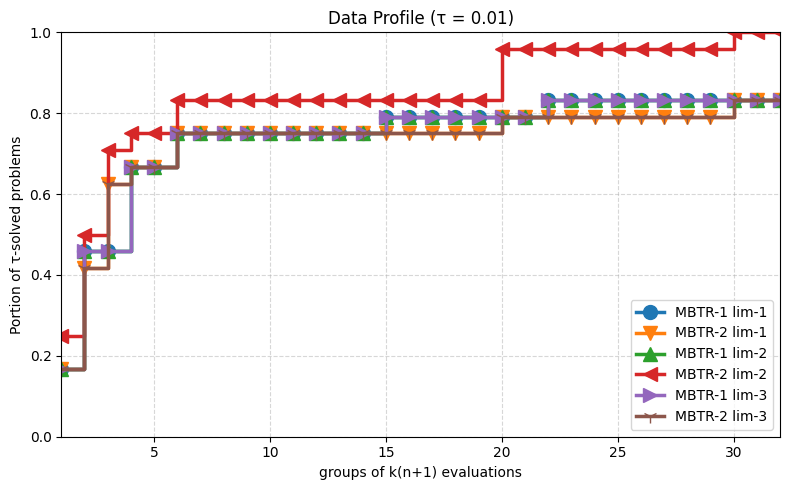

In [23]:
tau = 0.01
k_vals = torch.linspace(1, 32, 32)

problem_dims = torch.zeros(cap_n_problems)
for i in range(cap_n_problems):
    problem_dims[i] = cutest_wrapper.problems[i].n

profile_vals = profiles.data_profile(NUM_ALGS, cap_n_problems, log_paths, tau, problem_dims, k_vals)
profiles.plot_data_profile(profile_vals, tau, alg_names, k_vals)